In [9]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt

In [10]:
class Detector:
    def __init__ (self, 
                  name: str,
                  R: float,
                  N: int,
                  r: float,
                  a: float,
                 ):
        self.name = name
        self.R = R
        self.N = N
        self.r = r
        self.a = a

        self.coor, self.angl_pmt = self.make_coordinates()

    def make_coordinates(self):
        coor = []
        angl = []
    
        for i in range(self.N):
            z = 1 - 2 * (i + 0.5) / self.N
            phi = i * np.pi * (3 - np.sqrt(5))
            teta = np.arccos(z)
    
            x = self.R * np.sqrt(1 - z**2) * np.cos(phi)
            y = self.R * np.sqrt(1 - z**2) * np.sin(phi)
            z = self.R * z

    
            coor.append((x, y, z))
            angl.append((teta, phi))
    
        return coor, angl

    def poind_and_pmt(self, point):
        # расстояние между точкой и ФЭУ
        for i, pmt in enumerate(self.coor):
            pmt = np.array(pmt)
            point = np.array(point)

            r_buff = np.linalg.norm(point - pmt)
            if r_buff < self.r:
                return True, i
            
            # alpha = np.arccos(np.dot(pmt, point)) / self.R**2
            # if alpha*self.R < self.r
        return False, -505
        

    def plot(self):
        xyz = np.array(self.coor)
    
        fig = plt.figure(figsize=(8, 8))
        ax = fig.add_subplot(111, projection='3d')
    
        # Сфера
        u = np.linspace(0, 2*np.pi, 50)
        v = np.linspace(0, np.pi, 50)
    
        x = self.R * np.outer(np.cos(u), np.sin(v))
        y = self.R * np.outer(np.sin(u), np.sin(v))
        z = self.R * np.outer(np.ones_like(u), np.cos(v))
    
        ax.plot_surface(x, y, z, alpha=0.15)
    
        # ФЭУ
        ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=(self.r * 100)**2)
    
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")
    
        ax.set_box_aspect([1, 1, 1])
    
        plt.show()
    
    def print_coor(self):
        for i in range(self.N):
            print(f"N{i} ({self.coor[i][0]}, {self.coor[i][1]}, {self.coor[i][2]})")

    def __repr__(self) -> str:
        return f"Detector (name={self.name}, R={self.R}m, N={self.N}, r={self.r}m, a={self.a})"
                  

In [11]:
D1 = Detector("Student_D1", R = 2, r = 10*0.01, N = 40, a = 0.5)

In [12]:
D1

Detector (name=Student_D1, R=2m, N=40, r=0.1m, a=0.5)

In [13]:
D1.print_coor()

N0 (0.4444097208657797, 0.0, 1.95)
N1 (-0.5603518341292567, 0.5133281815641701, 1.85)
N2 (0.08464959396472493, -0.9645384628108966, 1.75)
N3 (0.6876974263760002, 0.8969795146801436, 1.65)
N4 (-1.244601496640145, -0.22015248025200784, 1.55)
N5 (1.162271004457094, -0.739341674869135, 1.45)
N6 (-0.38308131693045394, 1.4250434044683793, 1.35)
N7 (-0.7195908616956929, -1.385528416079602, 1.25)
N8 (1.5370178407119346, 0.5613164502606549, 1.15)
N9 (-1.5734251218192978, 0.6494870175976786, 1.05)
N10 (0.7459569101077301, -1.594066588402921, 0.95)
N11 (0.5418195274232567, 1.7274060320905558, 0.8500000000000001)
N12 (-1.604144516197528, -0.9296345363385542, 0.75)
N13 (1.8473119363548438, -0.40612634709030876, 0.6499999999999999)
N14 (-1.1059097378723761, 1.573042800332862, 0.55)
N15 (-0.25043103361693836, -1.9325590023079635, 0.44999999999999996)
N16 (1.5056985270770114, 1.2690043126633253, 0.3500000000000001)
N17 (-1.982618986751085, 0.08198751962403351, 0.25)
N18 (1.4136660403747419, -1.4067865

In [14]:
point_test = (0.4,0,1.95)

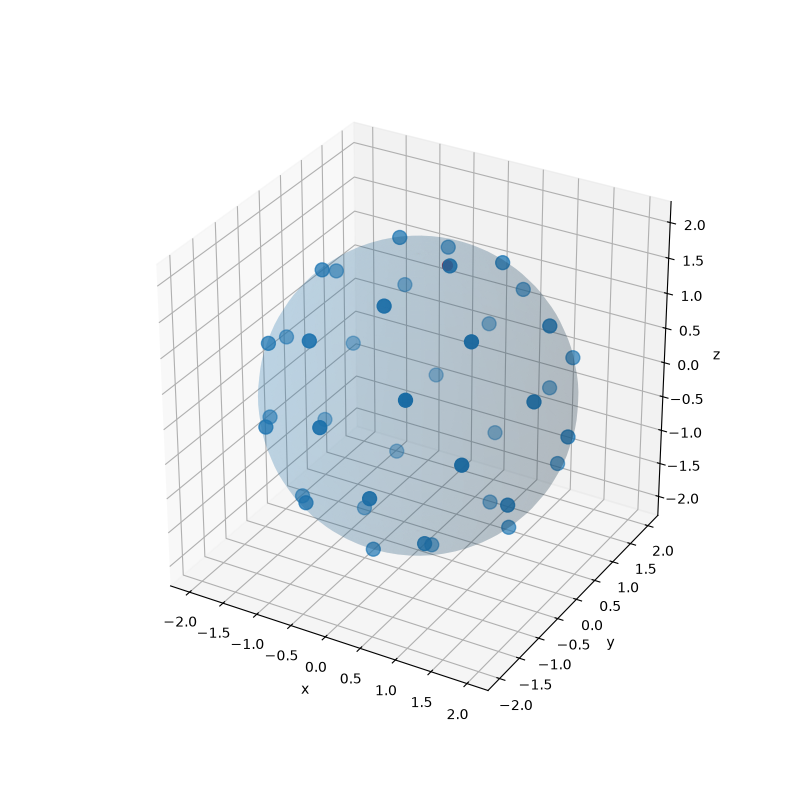

In [15]:
xyz = np.array(D1.coor)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Сфера
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)

x = D1.R * np.outer(np.cos(u), np.sin(v))
y = D1.R * np.outer(np.sin(u), np.sin(v))
z = D1.R * np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(x, y, z, alpha=0.15)

# ФЭУ
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=(D1.r * 100)**2)

# точка
p_test = np.array(point_test)
ax.scatter(p_test[0], p_test[1], p_test[2], s=50, color='red')

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_box_aspect([1, 1, 1])

plt.show()

In [16]:
D1.poind_and_pmt(point_test)

(True, 0)